# GPU Programming with Triton — Vector Addition
### *Lecture 1 · ~90 min · companion to Praktikum 3*

Today, we will build, run, measure, and break a single GPU kernel until we
understand it from the silicon up. By the end you will be able to walk into the
matrix-multiplication praktikum and recognise every primitive.

**The plan**

| § | Topic | What we show                                     |
|---|---|--------------------------------------------------|
| 1 | Why GPUs, why Triton | one slide of motivation                          |
| 2 | The SIMT mental model | grid → program → warp → thread                   |
| 3 | Our first kernel: scalar `c[i] = a[i] + b[i]` | line-by-line walk                                |
| 4 | Counting: programs, threads, FLOPs, bytes | derive **AI = 1/12**                             |
| 5 | The roofline | live plot — where does our kernel sit?           |
| 6 | Benchmark the naive kernel | GFLOPS and GB/s                  |
| 7 | Fix it: block kernel with `tl.arange` | new primitives                                   |
| 8 | Speedup | measure                                          |
| 9 | Block-size sweep | live plot                                        |
| 10 | vs `torch.add` | how close to vendor?                             |
| 10½ | *(optional)* peek at the generated PTX | demystify what Triton emits                      |
| 11 | Profile a run | `torch.profiler` + Perfetto                      |
| 12 | Reductions → dot product | `tl.sum` + `tl.atomic_add`                       |
| 13 | Reductions in practice → softmax | `max + exp + sum` fused, one row per program     |
| 14 | Ausblick | model parallelism · kernel fusion · tensor cores |
| 15 | Praktikum tasks | what to hand in                                  |

## 0 · Setup

Triton is a Python-embedded DSL that compiles to PTX. It needs a **CUDA GPU** —
Colab T4, Kaggle T4/P100, the EFI cluster, or a local NVIDIA box. The next cell
installs it and prints `cuda:0` if available.

In [18]:
try:
    import torch
    assert torch.cuda.is_available()
except (ImportError, AssertionError):
    !pip install -q torch --index-url https://download.pytorch.org/whl/cu124
    import torch

!pip install -q triton matplotlib

import time
import numpy as np
import matplotlib.pyplot as plt
import triton
import triton.language as tl

torch.manual_seed(0); torch.cuda.manual_seed_all(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("torch :", torch.__version__)
print("triton:", triton.__version__)

device: cuda
torch : 2.10.0+cu128
triton: 3.6.0


## 1 · Why GPUs, why Triton

Recap: A modern CPU has ~10 cores, each with deep out-of-order execution and big
caches. A modern GPU has ~10 000 simple cores grouped into ~50–100 *Streaming
Multiprocessors* (SMs), each with a tiny fast scratchpad (shared memory) and
fed by a wide DRAM bus.

Challenge: if your problem has *enough independent work* to feed every SM,
the GPU wins by 10–100×. If it doesn't — or if you stage the data wrong — the
GPU sits idle.

## 2 · The SIMT mental model

When you launch a Triton kernel you specify a **grid** — a 1-D, 2-D, or 3-D
array of *programs*. Each program is an independent piece of work. The GPU's
scheduler picks programs off the grid and assigns them to SMs as resources in SMs
become free.

*Figure 1 — Grid of programs scheduled onto SMs; each program runs as warps of 32 threads.*

Inside a program, **you do not write thread-level code**. You write
*vector-of-elements* code with `tl.arange`, `tl.load`, `tl.store`, and Triton
spreads those vectors across the program's threads automatically.

Three things to remember:
1. **`tl.program_id(axis)`** tells a program *which* program it is.
2. **All programs run the same code** — branching on `program_id` is how they
   specialise.
3. **The grid size is up to you.** Too few programs → SMs idle. Too many →
   scheduling overhead dominates.
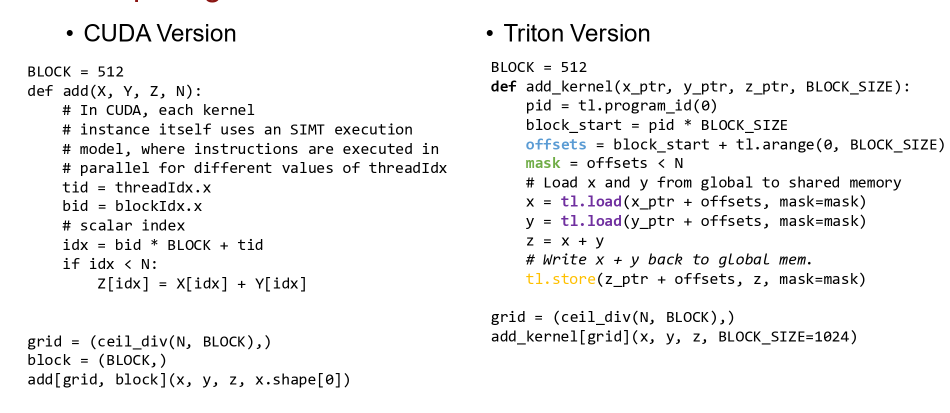

## 3 · Our first kernel — element-wise vector addition

We're going to compute the simplest non-trivial GPU function:

$$c_i = a_i + b_i, \quad i = 0, 1, \dots, N-1.$$

Why start here? Because it strips away every distraction (no reductions, no
2-D indexing, no shared memory) and lets us focus on the **launch model**.

**Strategy v1 (naive).** Launch one program per output element. Each program
loads one float from `a`, one from `b`, adds them, stores to `c`.

In [19]:
# ────────────────────────────────────────────────────────────────
# DEVICE side — runs on the GPU, one copy per program
# ────────────────────────────────────────────────────────────────
@triton.jit                                         # (1) DECORATOR — mark as a GPU kernel
def simple_vecadd_kernel(a_ptr, b_ptr, c_ptr, N):
    pid = tl.program_id(axis=0)                     # (2) which program am I?    ∈ [0, N)
    a_val = tl.load(a_ptr + pid)                    # (3) READ
    b_val = tl.load(b_ptr + pid)                    #     READ
    tl.store(c_ptr + pid, a_val + b_val)            # (4) COMPUTE + STORE


# ────────────────────────────────────────────────────────────────
# HOST side — ordinary Python, runs on the CPU
# ────────────────────────────────────────────────────────────────
def simple_vecadd(a, b):
    N = a.numel()
    c = torch.empty_like(a)                         # allocate the output
    grid = (N,)                                     # (5) GRID — N programs, 1-D
    simple_vecadd_kernel[grid](a, b, c, N)          # (6) LAUNCH
    return c

**Reading the kernel.** `@triton.jit` marks a Python function as a GPU
kernel. Inside, `tl.load(ptr)` and `tl.store(ptr, val)` are the only ways data
crosses the SM boundary to/from Global Memory. The pointer arithmetic is just integer offsets into
flat memory.

**The launch.** `kernel[grid](args...)` is the Triton equivalent of CUDA's
`<<<grid, block>>>`. Host code allocates `c` and launches the grid. Everything inside `@triton.jit` runs on the GPU.

### Test: does it work?

Verify against PyTorch's element-wise add. We use a small `N` so the
output is tractable.

In [20]:
N = 8
A = torch.arange(N, device=DEVICE, dtype=torch.float32)
B = torch.full((N,), 10.0, device=DEVICE)
C = simple_vecadd(A, B) # Add with Triton

print("A :", A.tolist())
print("B :", B.tolist())
print("C :", C.tolist())
torch.testing.assert_close(C, A + B)
print("OK")

A : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
B : [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
C : [10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0]
OK


## 4 · Counting — programs, threads, FLOPs, bytes

To predict performance we have to count four things.

For `N = 1024` and our naive kernel:

|  | per program | whole kernel |
|---|---:|---:|
| programs launched | 1 | **1024** |
| loads (4 B each) | 2 | 2 N |
| stores (4 B each) | 1 | N |
| FLOPs (one add) | 1 | N |
| **bytes moved** | 12 | **12 N** |

**Arithmetic Intensity** is the key derived quantity:

$$
\text{AI} \;=\; \frac{\text{FLOPs}}{\text{bytes moved}}
            \;=\; \frac{N}{12N}
            \;=\; \frac{1}{12} \;\;\approx\;\; 0.083 \;\;\text{FLOPs/byte}.
$$

Compare it to the GPU's compute-to-bandwidth ratio in the next section. It decides whether we're compute-bound or memory-bound, and therefore which options (math throughput vs DRAM bandwidth) we have to pull to go faster.

If you doubled the work — say `c[i] = a[i] + b[i] * b[i]` —
how would AI change?

*(Answer: 2 FLOPs / 12 bytes = 1/6. Still memory-bound.
You can't escape the bandwidth wall by doing more arithmetic on data you only
read once. To become compute-bound, you need to reuse data many times after loading it.)*

## 5 · The roofline

Every GPU has two ceilings:

- a **compute ceiling** (peak FLOPS) and
- a **bandwidth ceiling** (peak GB/s).

Plot achievable performance against arithmetic intensity and you get the
roofline:

A kernel with AI less than the ridge AI is memory-bound. I.e. left of ridge point, its peak is `BW × AI`. Otherwise compute-bound and its peak is `peak_FLOPS`.

In [21]:
props = torch.cuda.get_device_properties(0)
GPU_NAME = props.name

# Edit these to match your GPU's datasheet. Defaults are for a Tesla T4.
PEAK_FP32_TFLOPS = 8.1     # = SMs × FP32-cores/SM × 2 FLOP/cycle × clock_GHz
PEAK_FP16_TFLOPS = 65.0    # tensor cores
PEAK_BW          = 320.0   # GB/s

ridge_AI = PEAK_FP32_TFLOPS * 1e3 / PEAK_BW    # FLOPs/byte at the corner

print(f"GPU                          : {GPU_NAME}")
print(f"Compute capability           : {props.major}.{props.minor}")
print(f"Streaming multiprocessors    : {props.multi_processor_count}")
print(f"VRAM                         : {props.total_memory / 1024**3:.2f} GiB")
print(f"L2 cache                     : {props.L2_cache_size / 1024**2:.2f} MiB")
print(f"Shared memory / SM           : {props.shared_memory_per_block / 1024:.0f} KiB")
print()
print(f"Peak FP32                    : {PEAK_FP32_TFLOPS} TFLOPS")
print(f"Peak DRAM bandwidth          : {PEAK_BW} GB/s")
print(f"Ridge AI (compute / BW)      : {ridge_AI:.1f} FLOPs/byte")
print(f"Our kernel's AI              : 0.083 FLOPs/byte  ←  {ridge_AI/0.083:.0f}× below the ridge")

GPU                          : Tesla T4
Compute capability           : 7.5
Streaming multiprocessors    : 40
VRAM                         : 14.56 GiB
L2 cache                     : 4.00 MiB
Shared memory / SM           : 48 KiB

Peak FP32                    : 8.1 TFLOPS
Peak DRAM bandwidth          : 320.0 GB/s
Ridge AI (compute / BW)      : 25.3 FLOPs/byte
Our kernel's AI              : 0.083 FLOPs/byte  ←  305× below the ridge


The black line is the ceiling. We plot **two** points at AI = 1/12: the red **circle** is the theoretical *best case* at that AI (the ceiling itself, `PEAK_BW × AI`), and the orange **triangle** is what
`simple_vecadd` *actually* achieves on this GPU right now. The gap between
them is launch overhead.

The fact that both points are hugely to the left of the ridge means
**we are memory-bound**: peak achievable performance is just `PEAK_BW × AI`,
which is a tiny fraction of peak FLOPS. We need to figure out *why* the naive
kernel doesn't even reach the bandwidth ceiling.

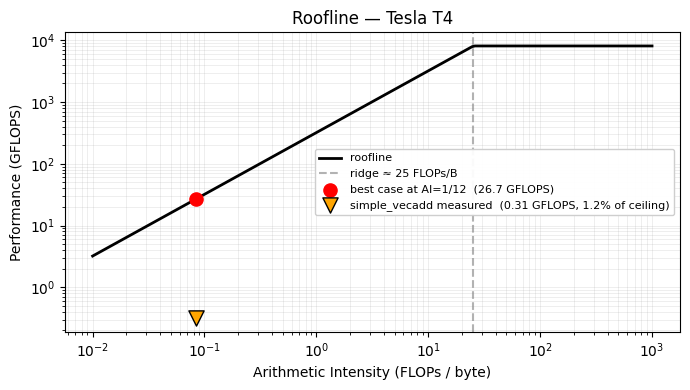

DRAM ceiling at AI=1/12 :  26.67 GFLOPS   (320 GB/s × 1/12)
  simple_vecadd measured:   0.31 GFLOPS   → 1.2% of ceiling, 3.4 ms / call


In [22]:
# Quick measured run of simple_vecadd so we can plot it on the roofline.
# (We don't have the `bench()` helper yet — that's defined in §6 — so we
#  do a one-off timing here with time.time() and torch.cuda.synchronize.)
N_meas = 1 << 20                                                # 1M elements
A_meas = torch.rand(N_meas, device=DEVICE, dtype=torch.float32)
B_meas = torch.rand(N_meas, device=DEVICE, dtype=torch.float32)
for _ in range(2):                                              # warmup
    simple_vecadd(A_meas, B_meas)
torch.cuda.synchronize()
_t0 = time.time()
for _ in range(5):                                              # naive kernel is SLOW, keep reps low
    simple_vecadd(A_meas, B_meas)
torch.cuda.synchronize()
t_naive_ms     = (time.time() - _t0) * 1000 / 5
naive_gflops   = N_meas / (t_naive_ms * 1e-3) / 1e9
ceiling_at_AI  = PEAK_BW * (1/12)                               # max GFLOPS at our AI

# --- Plot ---
ais     = np.logspace(-2, 3, 200)                               # 0.01 … 1000 FLOPs/byte
ceiling = np.minimum(PEAK_BW * ais, PEAK_FP32_TFLOPS * 1e3)     # GFLOPS

plt.figure(figsize=(7, 4))
plt.loglog(ais, ceiling, 'k-', lw=2, label="roofline")
plt.axvline(ridge_AI, color='gray', ls='--', alpha=0.6,
            label=f"ridge ≈ {ridge_AI:.0f} FLOPs/B")
plt.scatter([1/12], [ceiling_at_AI], color='red', zorder=5, s=90, marker='o',
            label=f"best case at AI=1/12  ({ceiling_at_AI:.1f} GFLOPS)")
plt.scatter([1/12], [naive_gflops], color='orange', edgecolor='black',
            zorder=6, s=120, marker='v',
            label=f"simple_vecadd measured  ({naive_gflops:.2f} GFLOPS, "
                  f"{100*naive_gflops/ceiling_at_AI:.1f}% of ceiling)")
plt.xlabel("Arithmetic Intensity (FLOPs / byte)")
plt.ylabel("Performance (GFLOPS)")
plt.title(f"Roofline — {GPU_NAME}")
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='center right', fontsize=8, framealpha=0.95)
plt.tight_layout(); plt.show()

print(f"DRAM ceiling at AI=1/12 : {ceiling_at_AI:6.2f} GFLOPS   ({PEAK_BW:.0f} GB/s × 1/12)")
print(f"  simple_vecadd measured: {naive_gflops:6.2f} GFLOPS   "
      f"→ {100*naive_gflops/ceiling_at_AI:.1f}% of ceiling, {t_naive_ms:.1f} ms / call")

## 6 · Benchmark the naive kernel

A small helper to measure mean kernel time, plus a converter to **effective
DRAM bandwidth**. For memory-bound kernels GB/s is the metric. It tells you
what fraction of the GPU's bandwidth you actually fed through.

In [23]:
def bench(fn, warmup=5, reps=50):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(reps):
        fn()
    torch.cuda.synchronize()
    return (time.time() - t0) * 1000 / reps          # ms

def gflops(N, ms):       return N / (ms * 1e-3) / 1e9
def gbps(N, ms, b=4, s=3): return s * b * N / (ms * 1e-3) / 1e9     # 3 streams: load A, load B, store C

def kernel_info(jit_fn):
    """Compile-time stats (regs, spills, shared mem, warps, stages) of any cached @triton.jit kernel."""
    cache = next((getattr(jit_fn, a) for a in ("device_caches", "cache") if hasattr(jit_fn, a)), None)
    if not cache: return None
    def find(o, d=0):
        if d > 5 or o is None: return None
        if hasattr(o, "metadata") and not isinstance(o, (dict, list, tuple)): return o
        if isinstance(o, dict):
            for v in o.values():
                r = find(v, d+1)
                if r is not None: return r
        elif isinstance(o, (list, tuple)):
            for v in o:
                r = find(v, d+1)
                if r is not None: return r
        return None
    k = find(cache)
    if k is None: return None
    m = k.metadata
    return dict(n_regs=getattr(k,"n_regs",None), n_spills=getattr(k,"n_spills",None),
                shared_bytes=getattr(m,"shared",None), num_warps=getattr(m,"num_warps",None),
                num_stages=getattr(m,"num_stages",None))

Now run it on a million elements and look at three numbers: wall time,
GFLOPS, and GB/s as a fraction of `PEAK_BW`.

In [24]:
N = 1 << 20                                       # 1 048 576 elements (~4 MiB / tensor)
A = torch.rand(N, device=DEVICE, dtype=torch.float32)
B = torch.rand(N, device=DEVICE, dtype=torch.float32)

t = bench(lambda: simple_vecadd(A, B))
print(f"naive vecadd   N = {N}")
print(f"  time         : {t:.3f} ms")
print(f"  GFLOPS       : {gflops(N, t):.2f}    ({100*gflops(N,t)/(PEAK_FP32_TFLOPS*1e3):.2f}% of compute peak)")
print(f"  GB/s         : {gbps(N, t):.2f}    ({100*gbps(N, t)/PEAK_BW:.1f}% of bandwidth peak)")
print(f"  kernel_info  : {kernel_info(simple_vecadd_kernel)}")

naive vecadd   N = 1048576
  time         : 3.261 ms
  GFLOPS       : 0.32    (0.00% of compute peak)
  GB/s         : 3.86    (1.2% of bandwidth peak)
  kernel_info  : {'n_regs': 6, 'n_spills': 0, 'shared_bytes': 0, 'num_warps': 4, 'num_stages': 3}


**What you should see.** A single-digit percentage of `PEAK_BW`. The
kernel is correct, the kernel is memory-bound, and yet we're nowhere near the
roofline ceiling we predicted. **Why?**

Because we launched **a million programs to do a million additions**.
The grid scheduler spends most of its time launching, retiring, and book-
keeping programs that do almost no work. The right amount of work per program
is much larger than 1 element.

## 7 A block-based kernel

The new idea: **`tl.arange(0, BLOCK_SIZE)`** — a *vector* of indices
`[0, 1, ..., BLOCK_SIZE-1]`. Adding it to a base offset gives you a vector
of `BLOCK_SIZE` element indices that you can hand to `tl.load` in one go.

> **Assumption for this section:** `N` is a multiple of `BLOCK_SIZE`, so every
> program's block lands fully inside the vector. We'll lift this assumption
> later (with a *mask* parameter) when the kernel needs to handle awkward
> tail blocks — for now we keep the code as small as possible.

In [25]:
# ────────────────────────────────────────────────────────────────
# DEVICE side — anatomy of a Triton kernel in 6 labelled steps
# ────────────────────────────────────────────────────────────────
@triton.jit                                            # (1) DECORATOR
def block_vecadd_kernel(a_ptr, b_ptr, c_ptr, N,
                        BLOCK_SIZE: tl.constexpr):     # (2) compile-time BLOCK SIZE
    pid  = tl.program_id(axis=0)                       # (3) BLOCK index — which block am I?
    offs = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE) # (4) OFFSETS — what indices do I touch?

    a = tl.load(a_ptr + offs)                          # (5) READ
    b = tl.load(b_ptr + offs)                          #     READ
    tl.store(c_ptr + offs, a + b)                      # (6) COMPUTE + STORE


# ────────────────────────────────────────────────────────────────
# HOST side
# ────────────────────────────────────────────────────────────────
def block_vecadd(a, b, BLOCK_SIZE=128, num_warps=4):
    N = a.numel()
    assert N % BLOCK_SIZE == 0, (
        f"N={N} must be divisible by BLOCK_SIZE={BLOCK_SIZE} "
        f"(this kernel intentionally omits masking)"
    )
    c = torch.empty_like(a)
    grid = (N // BLOCK_SIZE,)                          # (7) GRID — N / BLOCK_SIZE programs
    block_vecadd_kernel[grid](a, b, c, N,
                              BLOCK_SIZE=BLOCK_SIZE,
                              num_warps=num_warps)     # pinned so the layout is deterministic
    return c

**`tl.constexpr`** matters: `BLOCK_SIZE` is baked into the kernel at
**compile time**, not passed as a runtime argument. Triton recompiles the
kernel once per distinct `BLOCK_SIZE` value, which lets it generate the right
register/shared-memory layout for that size.

**Verify** on a power-of-two `N` (which is divisible by any sensible `BLOCK_SIZE`):

In [26]:
N = 1 << 20                                          # 1 M elements; cleanly divisible by 128
A = torch.rand(N, device=DEVICE, dtype=torch.float32)
B = torch.rand(N, device=DEVICE, dtype=torch.float32)
torch.testing.assert_close(block_vecadd(A, B, BLOCK_SIZE=128), A + B)
print("✓ N = 2^20, BLOCK_SIZE = 128 (every block is full)")

✓ N = 2^20, BLOCK_SIZE = 128 (every block is full)


## 8 · Speedup

Same `N`, same data, side-by-side. Watch the GB/s column.

In [27]:
N = 1 << 20
A = torch.rand(N, device=DEVICE, dtype=torch.float32)
B = torch.rand(N, device=DEVICE, dtype=torch.float32)

t_naive = bench(lambda: simple_vecadd(A, B))
t_block = bench(lambda: block_vecadd(A, B, BLOCK_SIZE=128))

print(f"{'kernel':<22} {'time (ms)':>10}  {'GB/s':>8}  {'% peak':>8}")
print("-" * 54)
for name, t in [("naive (1 prog/elem)", t_naive), ("block (BS=128)", t_block)]:
    print(f"{name:<22} {t:>10.4f}  {gbps(N,t):>8.1f}  {100*gbps(N,t)/PEAK_BW:>7.1f}%")
print(f"\nspeedup: {t_naive / t_block:.1f}×")

kernel                  time (ms)      GB/s    % peak
------------------------------------------------------
naive (1 prog/elem)        2.1270       5.9      1.8%
block (BS=128)             0.0522     241.0     75.3%

speedup: 40.7×


**Why the jump.** Same FLOPs, same bytes, same AI. The *only* thing that
changed is **work-per-program**. A program is now 128 adds, so launch
overhead is amortised over a hundred operations instead of one. The grid
shrank from 1 M programs to 8192 — the scheduler can keep the SMs steadily fed.

**Hard ceiling.** No `BLOCK_SIZE` will get us above `PEAK_BW`. The arithmetic
intensity is fixed at `1/12` because every output is read and written exactly
once.

### Where do we *actually* sit on the roofline?

§5 showed the roofline with only the theoretical ceiling. Now we have
**measured** numbers for both kernels — but there's a subtlety.

⚠️ **Choose `N` so the working set spills out of L2.** Our `N = 2²⁰`
benchmark above uses two 4 MiB tensors. The T4 has a 4 MiB L2 cache, so
across the 50 bench reps most loads hit L2 instead of DRAM — and L2 has
*much* higher bandwidth than DRAM. The kernel appears to *exceed* the
DRAM ceiling, which is a fingerprint of caching, not a magical speedup.

To measure the real DRAM-bound performance we re-benchmark at `N = 2²²`
(~16 MiB per tensor, ~48 MiB working set — well past L2). Both kernels
still have **the same AI** (`1/12 FLOPs/byte`) because they do the same
algorithm. Optimization moves us **vertically up the bandwidth-bound
slope**, not horizontally. To move right (towards the ridge) you'd have
to change the *algorithm*.

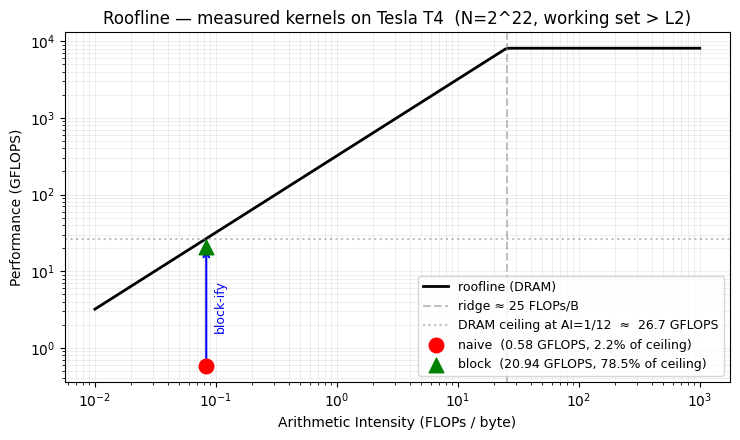

DRAM ceiling at AI = 1/12 :   26.7 GFLOPS   (320 GB/s × 1/12)
  naive :    0.58 GFLOPS  →    2.2% of ceiling
  block :   20.94 GFLOPS  →   78.5% of ceiling


In [28]:
# Re-benchmark on a working set that doesn't fit in L2 cache, so DRAM is
# the binding ceiling. (The naive kernel is slow → fewer reps to keep
# the live demo snappy.)
N_rl = 1 << 22                                                  # 4 M elements; ~48 MiB working set
A_rl = torch.rand(N_rl, device=DEVICE, dtype=torch.float32)
B_rl = torch.rand(N_rl, device=DEVICE, dtype=torch.float32)
t_naive_rl = bench(lambda: simple_vecadd(A_rl, B_rl),               warmup=2, reps=10)
t_block_rl = bench(lambda: block_vecadd(A_rl, B_rl, BLOCK_SIZE=128))

ais     = np.logspace(-2, 3, 200)
ceiling = np.minimum(PEAK_BW * ais, PEAK_FP32_TFLOPS * 1e3)         # GFLOPS

AI            = 1.0 / 12
naive_gflops  = gflops(N_rl, t_naive_rl)
block_gflops  = gflops(N_rl, t_block_rl)
ceiling_at_AI = PEAK_BW * AI                                        # max GFLOPS at our AI (DRAM only)

plt.figure(figsize=(7.5, 4.5))
plt.loglog(ais, ceiling, 'k-', lw=2, label="roofline (DRAM)")
plt.axvline(ridge_AI, color='gray', ls='--', alpha=0.5,
            label=f"ridge ≈ {ridge_AI:.0f} FLOPs/B")
plt.axhline(ceiling_at_AI, color='gray', ls=':', alpha=0.5,
            label=f"DRAM ceiling at AI=1/12  ≈  {ceiling_at_AI:.1f} GFLOPS")
plt.scatter([AI], [naive_gflops], color='red',   s=110, zorder=5,
            label=f"naive  ({naive_gflops:.2f} GFLOPS, {100*naive_gflops/ceiling_at_AI:.1f}% of ceiling)")
plt.scatter([AI], [block_gflops], color='green', s=110, zorder=5, marker='^',
            label=f"block  ({block_gflops:.2f} GFLOPS, {100*block_gflops/ceiling_at_AI:.1f}% of ceiling)")
plt.annotate("", xy=(AI, block_gflops), xytext=(AI, naive_gflops),
             arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
plt.text(AI * 1.15, np.sqrt(max(naive_gflops, 1e-6) * block_gflops),
         "block-ify", color='blue', fontsize=9, rotation=90, va='center')
plt.xlabel("Arithmetic Intensity (FLOPs / byte)")
plt.ylabel("Performance (GFLOPS)")
plt.title(f"Roofline — measured kernels on {GPU_NAME}  (N=2^22, working set > L2)")
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print(f"DRAM ceiling at AI = 1/12 :  {ceiling_at_AI:5.1f} GFLOPS   ({PEAK_BW:.0f} GB/s × 1/12)")
print(f"  naive : {naive_gflops:7.2f} GFLOPS  →  {100*naive_gflops/ceiling_at_AI:5.1f}% of ceiling")
print(f"  block : {block_gflops:7.2f} GFLOPS  →  {100*block_gflops/ceiling_at_AI:5.1f}% of ceiling")

**Reading the plot.** Both dots sit on the vertical line `AI = 1/12`.
The naive kernel is far below the ceiling. The gap is **launch overhead**,
not bandwidth. The block kernel sits near the DRAM ceiling: that's where it
should be, and you can't go higher *with this algorithm* on data that doesn't
fit in cache.

Notice the green triangle is nowhere near the *top* compute ceiling — that's
the whole point. **Memory-bound kernels are bounded by the diagonal, not the
plateau.** No amount of FP32 cleverness will help; only feeding data faster.

> 💡 **About the cache surprise.** If you re-run the same plot with `N = 2²⁰`
> the block kernel will appear to sit *above* the DRAM ceiling — sometimes
> 10× higher. That's not a measurement error; it's the L2 doing real work.
> A more faithful roofline would draw a *second*, higher ceiling for L2
> bandwidth (~2 TB/s on a T4) and a third for shared memory. We collapse
> them into one DRAM line here for clarity, but in real performance work
> you keep all three ceilings in mind and ask: *which one is binding for
> my working set?*

### Aside: can we raise AI?

AI is a property of the **algorithm**,not the implementation. `c[i] = a[i] + b[i]` does exactly 1 FLOP per element
and *must* move 12 bytes per element (read A, read B, write C — every output
depends on never-before-seen inputs, so nothing can be skipped). `AI = 1/12`
is an algorithmic invariant. No `BLOCK_SIZE` change, no shared-memory trick,
no register tiling will move that red/green dot to the right.

To raise AI you have to **change the problem**. Three real levers:

| Lever | What it does | AI for an element-wise op | Where you'll see it |
|---|---|---|---|
| **Lower precision** (FP16/BF16/INT8) | Halves the bytes; FLOPs unchanged | `1/6` — still memory-bound | Free with `tl.dot` on modern GPUs (tensor cores) |
| **Data reuse** | Use each loaded value for *many* outputs | grows like `~BLOCK/2` | The matmul praktikum — every A-row feeds N output columns |

Matmul has a `load → multiply → accumulate` inner loop similar in shape to your `load → add → store` here,
but each element of A feeds `N` output elements (once per column of B).
That alone takes AI from `1/12` to `~BLOCK/2 ≈ 32` at `BLOCK=64`, comfortably
**right of the ridge**. The kernel becomes *compute-bound*.

## 9 · Block-size sweep

What's the *right* `BLOCK_SIZE`? Sweep it and plot.

- Too small: launch overhead dominates again.
- Too large: registers run out, occupancy drops, scheduling gets coarse.

BLOCK_SIZE         ms       GB/s   % peak
         2     14.793       13.6     4.3%
         4      7.657       26.3     8.2%
         8      3.922       51.3    16.0%
        16      2.141       94.0    29.4%
        32      1.188      169.5    53.0%
        64      0.793      254.0    79.4%
       128      0.781      257.9    80.6%
       256      0.796      253.0    79.1%
       512      0.827      243.5    76.1%
      1024      0.842      239.1    74.7%
      2048      0.844      238.5    74.5%
      4096      0.844      238.5    74.5%
      8192      0.848      237.5    74.2%


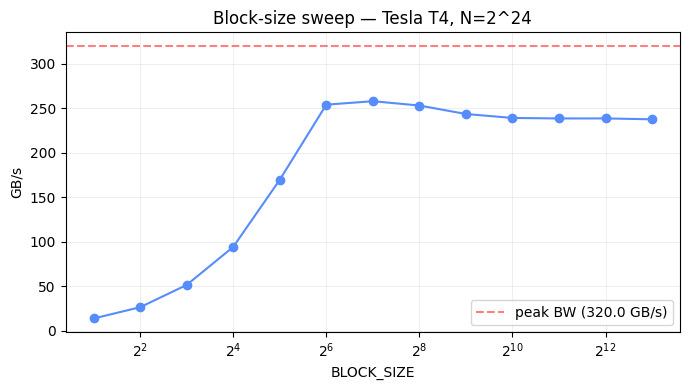

In [29]:
N = 1 << 24                                        # 16 M elements
A = torch.rand(N, device=DEVICE, dtype=torch.float32)
B = torch.rand(N, device=DEVICE, dtype=torch.float32)

block_sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
bws = []
print(f"{'BLOCK_SIZE':>10} {'ms':>10} {'GB/s':>10} {'% peak':>8}")
for BS in block_sizes:
    t = bench(lambda: block_vecadd(A, B, BLOCK_SIZE=BS))
    bw = gbps(N, t)
    bws.append(bw)
    print(f"{BS:>10} {t:>10.3f} {bw:>10.1f} {100*bw/PEAK_BW:>7.1f}%")

plt.figure(figsize=(7, 4))
plt.semilogx(block_sizes, bws, 'o-', base=2)
plt.axhline(PEAK_BW, color='red', ls='--', alpha=0.5, label=f"peak BW ({PEAK_BW} GB/s)")
plt.xlabel("BLOCK_SIZE")
plt.ylabel("GB/s")
plt.title(f"Block-size sweep — {GPU_NAME}, N=2^24")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

## 10 · How close to the vendor kernel?

`torch.add` calls a hand-tuned CUDA kernel. Sweep `N` from 64 K up to ~64 M. Faster, due to Assumption: No Masking

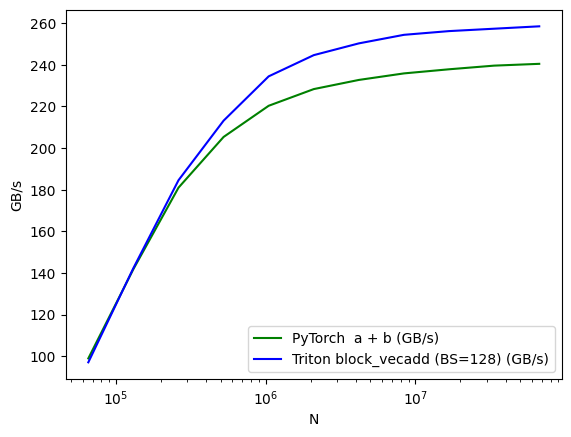

vecadd-fp32:
             N  PyTorch  a + b (GB/s)  Triton block_vecadd (BS=128) (GB/s)
0      65536.0              98.905138                            97.022401
1     131072.0             141.848053                           142.320865
2     262144.0             180.987697                           184.549332
3     524288.0             205.357704                           213.185728
4    1048576.0             220.344104                           234.485956
5    2097152.0             228.361861                           244.682737
6    4194304.0             232.764638                           250.337001
7    8388608.0             235.903201                           254.446979
8   16777216.0             237.882420                           256.235511
9   33554432.0             239.638519                           257.385643
10  67108864.0             240.501801                           258.532623


In [30]:
import triton.testing

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names    = ["N"],
        x_vals     = [2 ** i for i in range(16, 27)],   # 64K → 64M
        x_log      = True,
        line_arg   = "provider",
        line_vals  = ["torch", "triton"],
        line_names = ["PyTorch  a + b",  "Triton block_vecadd (BS=128)"],
        styles     = [("green", "-"), ("blue", "-")],
        ylabel     = "GB/s",
        plot_name  = "vecadd-fp32",
        args       = {},
    )
)
def benchmark(N, provider):
    a = torch.rand(N, device=DEVICE, dtype=torch.float32)
    b = torch.rand(N, device=DEVICE, dtype=torch.float32)
    fn = (lambda: a + b) if provider == "torch" else (lambda: block_vecadd(a, b, BLOCK_SIZE=128))
    ms = triton.testing.do_bench(fn)
    return gbps(N, ms)

benchmark.run(show_plots=True, print_data=True)

**Reading the plot.**
- For tiny `N`, both kernels are dominated by launch overhead — flat-low.
- Around `N ≈ 2²⁰` they start to climb as the SMs fill up.
- They asymptote at the GPU's effective DRAM bandwidth.

The Triton kernel typically lands within ~10% of the PyTorch kernel for an
op this simple. That's a great deal: **two lines of meaningful code** versus
a hand-written CUDA kernel.

## 10½ · Optional: peek at the generated PTX

### What writing CUDA by hand makes *you* manage

To get good performance out of a GPU in CUDA C/C++, **you** are responsible
for four problems that have nothing to do with your algorithm:

1. **Memory coalescing (locality).** The 32 threads of a warp must read or
   write *contiguous* addresses, otherwise the hardware splits the access
   into multiple DRAM transactions and bandwidth collapses.
2. **Shared-memory management.** Each SM has ~100 KB of fast on-chip
   scratchpad. You stage tiles of data into it manually, mind the 32 banks
   (avoid bank conflicts), and `__syncthreads()` between phases.
3. **Intra-SM scheduling — occupancy.** Each thread costs registers; each
   block costs shared memory. Use too much of either and the SM keeps fewer
   warps resident, so it can't hide DRAM latency.
4. **Inter-SM scheduling.** With thousands of blocks across tens of SMs, the
   *order* they execute interacts with the L2 cache (Swizzling).

Plus: you debug by reading PTX assembly, profile with Nsight Compute, and
generally spend a lot of time in tools that don't speak Python.

### What Triton does for you

Triton **automates (4) entirely** (you write a 1-D / 2-D grid and the runtime
schedules it), **simplifies (3)** (its compiler picks register / warp counts
and `num_stages` for software pipelining), and gives you **(1) and (2) almost
for free** — `tl.load` of a contiguous range *is* a coalesced load, and
`tl.dot` stages tiles into shared memory under the hood.

Triton caches the **compiled kernel object**, which exposes the intermediate forms it generated:
`ttir` (Triton IR) → `ttgir` (Triton-GPU IR) → `llir` (LLVM IR) → **`ptx`**
(NVIDIA's GPU assembly) → `cubin` (binary). For an A100 / H100 production
kernel you'd inspect PTX to verify coalescing and the use of tensor-core
instructions. Here we just want to see that our 7-line kernel turns into
real assembly with `ld.global` / `st.global` instructions.

In [31]:
def get_compiled(jit_fn):
    cache = next((getattr(jit_fn, a) for a in ("device_caches", "cache") if hasattr(jit_fn, a)), None)
    def find(o, d=0):
        if d > 5 or o is None: return None
        if hasattr(o, "asm"): return o
        if isinstance(o, dict):
            for v in o.values():
                r = find(v, d + 1)
                if r is not None: return r
        elif isinstance(o, (list, tuple)):
            for v in o:
                r = find(v, d + 1)
                if r is not None: return r
        return None
    return find(cache)


# Force a BLOCK_SIZE=1024 compile here, because that variant produces the
# richer PTX with vectorised v4.b32 loads (8 elements per thread). At our
# default BLOCK_SIZE=128 each thread only owns 1 element → scalar loads,
# much shorter PTX. Try changing the value below and re-running to compare.
_N = 1 << 16
_A = torch.rand(_N, device=DEVICE, dtype=torch.float32)
_B = torch.rand(_N, device=DEVICE, dtype=torch.float32)
block_vecadd(_A, _B, BLOCK_SIZE=1024); torch.cuda.synchronize()

ck = get_compiled(block_vecadd_kernel)
if ck is not None and "ptx" in ck.asm:
    ptx = ck.asm["ptx"]
    print(f"available IR stages: {sorted(ck.asm.keys())}")
    print(f"PTX size           : {len(ptx)} bytes  ({len(ptx.splitlines())} lines)")
    print(f"\n----- full PTX -----")
    print(ptx)
else:
    print("Couldn't reach the cached kernel — run block_vecadd once first.")

available IR stages: ['cubin', 'llir', 'ptx', 'source', 'ttgir', 'ttir']
PTX size           : 4298 bytes  (142 lines)

----- full PTX -----
//
// Generated by LLVM NVPTX Back-End
//

.version 8.7
.target sm_75
.address_size 64

	// .globl	block_vecadd_kernel     // -- Begin function block_vecadd_kernel
                                        // @block_vecadd_kernel
.visible .entry block_vecadd_kernel(
	.param .u64 .ptr .global .align 1 block_vecadd_kernel_param_0,
	.param .u64 .ptr .global .align 1 block_vecadd_kernel_param_1,
	.param .u64 .ptr .global .align 1 block_vecadd_kernel_param_2,
	.param .u32 block_vecadd_kernel_param_3,
	.param .u64 .ptr .global .align 1 block_vecadd_kernel_param_4,
	.param .u64 .ptr .global .align 1 block_vecadd_kernel_param_5
)
.reqntid 128
{
	.reg .b32 	%r<9>;
	.reg .b64 	%rd<8>;
	.loc	1 5 0                           // 1092105718.py:5:0
$L__func_begin0:
	.loc	1 5 0                           // 1092105718.py:5:0

// %bb.0:
	ld.param.b64 	%rd4, [block_veca

**What to look for.** A `.visible .entry block_vecadd_kernel` symbol,
some `ld.global.b32` (load 32-bit float from global memory), arithmetic
(`add.f32`), and `st.global.b32` (store). If you see `ld.global.v4.b32` —
that's a **vectorised** 128-bit load, four floats in one transaction. That's
coalescing happening in the hardware, exactly because `tl.load(ptr + offs)`
asked for a contiguous range.

## 11 · Profile a real run

Numbers in tables are useful; **traces** are illuminating. Capture 10 iterations
with `torch.profiler` and open the JSON in <https://ui.perfetto.dev>. You'll
see CPU launch activity, the GPU kernel timeline, and the gap between them
(synchronisation cost).

In [32]:
import torch.profiler

N_PROF = 1 << 24
A_p = torch.rand(N_PROF, device=DEVICE, dtype=torch.float32)
B_p = torch.rand(N_PROF, device=DEVICE, dtype=torch.float32)
TRACE_PATH = "vecadd_trace.json"   # adjust on Kaggle/Colab

for _ in range(5):                              # warmup so JIT compile time isn't in the trace
    block_vecadd(A_p, B_p, BLOCK_SIZE=128)
torch.cuda.synchronize()

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
) as prof:
    for _ in range(10):
        with torch.profiler.record_function("block_vecadd_BS128"):
            block_vecadd(A_p, B_p, BLOCK_SIZE=128)
    torch.cuda.synchronize()

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=5))
prof.export_chrome_trace(TRACE_PATH)
print(f"\nopen this file in https://ui.perfetto.dev → {TRACE_PATH}")

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
        block_vecadd_kernel         0.00%       0.000us         0.00%       0.000us       0.000us       3.925ms       100.00%       3.925ms     784.918us             5  
         block_vecadd_BS128         0.00%       0.000us         0.00%       0.000us       0.000us       3.925ms       100.00%       3.925ms     784.918us             5  
         block_vecadd_BS128         8.08%     799.148us        30.93%       3.059ms     305.923us       0.000us         0.00%       0.000us       0.0

**What to look for in Perfetto.**
- A row of green CUDA kernel boxes — these are our `block_vecadd_kernel` runs.
- The gap between adjacent CUDA boxes — that's CPU-side launch overhead.
  If the gap is wider than the kernel itself, you're CPU-bound, not GPU-bound.
- Each box's width is your **lower bound**: at peak BW it should be
  `12·N / PEAK_BW = 12·2²⁴ / 320e9 ≈ 0.6 ms`. How close are you?

## 12 · Reductions: vector × vector → **scalar**

Element-wise ops are easy because programs are independent. A **dot product**
$$s = \sum_{i=0}^{N-1} a_i \cdot b_i$$
is harder: every program has to contribute to the *same* output. This is your
first encounter with cross-program coordination.

Two-stage strategy:

1. Each program reduces its own block with `tl.sum(...)`.
2. Partial sums are combined into a single output cell with `tl.atomic_add`.

`atomic_add` is a hardware-level read-modify-write that serialises concurrent
updates to the same address. It's slower than a normal store, but for ≤ a few
thousand contributions it's a perfectly fine final-stage reduction.

In [34]:
@triton.jit
def dot_kernel(a_ptr, b_ptr, out_ptr, N, BLOCK_SIZE: tl.constexpr):
    pid  = tl.program_id(axis=0)
    offs = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offs < N

    a = tl.load(a_ptr + offs, mask=mask, other=0.0)   # `other=0.0` makes masked lanes contribute zero
    b = tl.load(b_ptr + offs, mask=mask, other=0.0)

    block_sum = tl.sum(a * b, axis=0)                 # within-program reduction (warp shuffle)
    tl.atomic_add(out_ptr, block_sum)                 # across-program reduction


def dot(a, b, BLOCK_SIZE=1024):
    N = a.numel()
    out = torch.zeros(1, device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(N, BLOCK_SIZE),)
    dot_kernel[grid](a, b, out, N, BLOCK_SIZE=BLOCK_SIZE)
    return out[0]


N = 1 << 20
A = torch.rand(N, device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand(N, device=DEVICE, dtype=torch.float32) - 0.5

ref = torch.dot(A, B)
got = dot(A, B)
print(f"torch.dot   : {ref.item():.6f}")
print(f"triton dot  : {got.item():.6f}")
torch.testing.assert_close(got, ref, atol=1e-3, rtol=1e-3)
print("OK matches (loose tolerance — see note below)")

torch.dot   : -121.773514
triton dot  : -121.773582
OK matches (loose tolerance — see note below)


⚠️ **Why the loose tolerance?** `atomic_add` reduces in
non-deterministic order, and floating-point addition is **not associative**:
`(a + b) + c ≠ a + (b + c)` at the bit level. Two runs of this kernel can
disagree in the last few mantissa bits. PyTorch's reference uses a
deterministic tree reduction so its result is bit-stable but not "more
correct" — both are within rounding error.

## 14 · Ausblick

The body of this lecture covered the smallest GPU kernel that actually
demonstrates the SIMT model end-to-end. Real performance work goes much
further. Three directions worth knowing about:

**1 · Praktikum 3 — matmul on the GPU.** Same primitives, 2-D grid, `tl.dot`
replaces scalar `*`, AI rises from `1/12` to `~BLOCK/2` FLOPs/byte. You
finally cross the roofline ridge into compute-bound territory and start
caring about tensor cores.

**2 · Model parallelism.** A single GPU isn't enough for modern LLMs. Three
orthogonal ways to split the work:
- **Data parallel** — same model, different batches per GPU.
- **Tensor parallel** — split each weight matrix across GPUs (an `all-reduce`
  inside every layer).
- **Pipeline parallel** — split *layers* across GPUs, stream micro-batches
  through the pipeline.

These are *system-level* concerns; the per-GPU kernels are still Triton-style
matmuls and softmaxes underneath.

**3 · Mega-kernels and kernel fusion.** Every separate kernel launch costs a
DRAM round-trip. The frontier is folding `Q·K → softmax → ·V` into **one**
kernel that never spills the intermediate to DRAM. That's
[FlashAttention](https://arxiv.org/abs/2205.14135), and it's pure Triton.
`torch.compile` does this automatically for many op patterns — and the
generated code is Triton you can read.

**4 · Tensor cores.** Hopper / Ampere GPUs have specialised matrix-multiply
units that do `16 × 16 × 16` FP16/BF16 matmuls in a single instruction at
5–10× FP32 peak. `tl.dot` already uses them when inputs are FP16/BF16 — you
get them for free in the praktikum. Catch: tensor-core throughput is
**hardware-specific** (H100 ≠ A100 ≠ T4), so production kernels often need
per-architecture tuning via `triton.autotune`.

### Where to go next
- Triton tutorials [03 (matmul)](https://triton-lang.org/main/getting-started/tutorials/03-matrix-multiplication.html),
  [05 (layer-norm)](https://triton-lang.org/main/getting-started/tutorials/05-layer-norm.html),
  [06 (fused attention)](https://triton-lang.org/main/getting-started/tutorials/06-fused-attention.html).
- [`torch.compile` internals](https://pytorch.org/docs/stable/torch.compiler.html) — read the Triton it spits out.
- [FlashAttention 2 paper](https://arxiv.org/abs/2307.08691) — Triton-style kernel walkthrough.
- Nsight Compute — when 80% of CUDA performance isn't enough.

## 15 · Wrap-up

You now know:

| Concept | Where it appeared |
|---|---|
| `@triton.jit`, grid launch `kernel[grid](...)` | §3 |
| `tl.program_id` — programs differentiate themselves | §3 |
| `tl.load` / `tl.store` — only way data crosses the SM | §3 |
| `tl.arange` — vectorised indices | §7 |
| `tl.constexpr` — compile-time block size | §7 |
| Arithmetic intensity, roofline | §4–5 |
| GB/s as the right metric for memory-bound ops | §6, §8 |
| `BLOCK_SIZE` tuning vs occupancy | §9 |
| `triton.testing.perf_report` | §10 |
| Reading the compiled PTX *(optional)* | §10½ |
| `torch.profiler` + Perfetto | §11 |
| Reductions: `tl.sum` + `tl.atomic_add` | §12 |
| Multi-reduction kernel: softmax (`max` + `exp` + `sum`) | §13 |
| Where this scales: model parallelism · fusion · tensor cores | §14 |

In the praktikum (`l2-triton_matmul.ipynb`) every one of these reappears —
but the kernel is **2-D**, the reduction is the inner-product loop along `K`,
`tl.dot` replaces scalar `*`, and AI rises from `1/12` to `~BLOCK/2`. That
last change is what finally pushes you across the roofline ridge into
**compute-bound** territory, where the tensor cores live.

---

### References
- [Triton tutorial — Vector Addition](https://triton-lang.org/main/getting-started/tutorials/01-vector-add.html)
- [Triton language reference](https://triton-lang.org/main/python-api/triton.language.html)
- Williams, Waterman, Patterson — *Roofline: An Insightful Visual Performance Model* (CACM 2009)
- NVIDIA — [CUDA C Programming Guide § Programming Model](https://docs.nvidia.com/cuda/cuda-c-programming-guide/index.html#programming-model)